# 🍎 SmartFridge AI - Detección de Ingredientes con YOLOv8

## 🎯 Objetivo del Proyecto
Desarrollar un sistema de visión artificial capaz de identificar y localizar ingredientes dentro de un refrigerador. A diferencia de los modelos anteriores de clasificación, utilizaremos **YOLOv8 (You Only Look Once)** para realizar **Detección de Objetos**, lo que nos permite saber exactamente qué ingredientes hay y cuántos de cada uno.

## 🚀 ¿Por qué YOLOv8?
* **Transfer Learning:** Utiliza un modelo pre-entrenado en el dataset COCO, lo que permite obtener alta precisión con pocos datos.
* **Velocidad y Precisión:** Es el estándar actual de la industria para aplicaciones en tiempo real.
* **Localización:** No solo nos dice "hay un tomate", sino que dibuja un recuadro alrededor de él.

In [ ]:
# Instalación de librerías necesarias
!pip install ultralytics -q
!pip install roboflow -q
import os
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
import matplotlib.pyplot as plt
import cv2
import glob
import random

print("✅ Entorno configurado correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Entorno configurado correctamente.


## 📥 2. Descarga del Dataset desde Roboflow
Utilizaremos el dataset `whatsinyourfridge` versión 5, descargado directamente en formato compatible con YOLOv8. Este formato incluye un archivo `data.yaml` que contiene las rutas de las imágenes y los nombres de las 84 clases de alimentos.

In [ ]:
apiKey = "ZNLr9Hy3JaoipK5TvIzf"

rf = Roboflow(api_key=apiKey)
project = rf.workspace("whats-in-my-fridge").project("whatsinyourfridge")
dataset = project.version(5).download("yolov8")

# Ruta del archivo de configuración necesario para el entrenamiento
yaml_path = os.path.join(dataset.location, "data.yaml")
print(f"📂 Dataset listo. Archivo YAML en: {yaml_path}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Whatsinyourfridge-5 in yolov8:: 100%|██████████| 14214/14214 [00:02<00:00, 6413.33it/s]


📂 Dataset listo. Archivo YAML en: /content/Whatsinyourfridge-5/data.yaml


### 🔬 3. Entrenamiento con Reproducibilidad Garantizada

Para asegurar la integridad científica del experimento y permitir que los resultados sean replicables por terceros (incluyendo la corrección de este proyecto), se han fijado los siguientes parámetros de control:

* **`seed=0`**: Establece una semilla inicial fija para los generadores de números pseudoaleatorios. Esto asegura que la inicialización de pesos y la división de lotes (batches) sean idénticas en cada ejecución.
* **`deterministic=True`**: Fuerza el uso de algoritmos deterministas en la GPU, eliminando las variaciones estocásticas típicas del entrenamiento con CUDA.

De esta forma, si se re-ejecuta este cuaderno, se obtendrán métricas consistentes con las presentadas en la memoria.

In [ ]:
# Cargamos el modelo pre-entrenado
model = YOLO('yolov8s.pt')

print("Iniciando entrenamiento reproducible (Seed=0)...")

results = model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    name='SmartFridge_YOLOv8',
    exist_ok=True,
    seed=0,
    deterministic=True
)

# ✅ AQUÍ defines results_path correctamente
results_path = results.save_dir
print(f"Resultados en: {results_path}")

🚀 Iniciando entrenamiento reproducible (Seed=0)...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Whatsinyourfridge-5/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=SmartFridge_YOLOv8, nbs=64, nms=False, opse

## 👁️ 4. Pruebas Visuales (Inferencia)
Esta es la prueba definitiva. Seleccionamos imágenes aleatorias que el modelo **nunca ha visto** (del set de validación) y le pedimos que detecte los ingredientes. Esto demuestra la capacidad real de la IA en un entorno práctico.

📊 Generando Reporte de Clasificación para YOLO...
Procesando 1405 imágenes de validación...


  0%|          | 0/1405 [00:00<?, ?it/s]


📝 REPORTE DE CLASIFICACIÓN (Estilo Modelo Anterior)
                precision    recall  f1-score   support

        almond       0.74      0.93      0.82        15
         apple       0.88      0.91      0.89       112
     asparagus       0.82      0.79      0.81        29
       avocado       1.00      0.72      0.84        61
  bakingpowder       0.80      0.44      0.57         9
    bakingsoda       1.00      0.80      0.89         5
        banana       0.97      0.84      0.90       101
     bayleaves       0.00      0.00      0.00         2
          beef       1.00      0.83      0.91         6
    bellpepper       0.93      0.88      0.90        74
         bread       0.84      0.61      0.71        67
      broccoli       0.98      0.91      0.94        45
        butter       0.89      0.86      0.88        29
       cabbage       0.83      0.71      0.77         7
        carrot       0.93      0.86      0.89        59
   cauliflower       1.00      1.00      1.00     

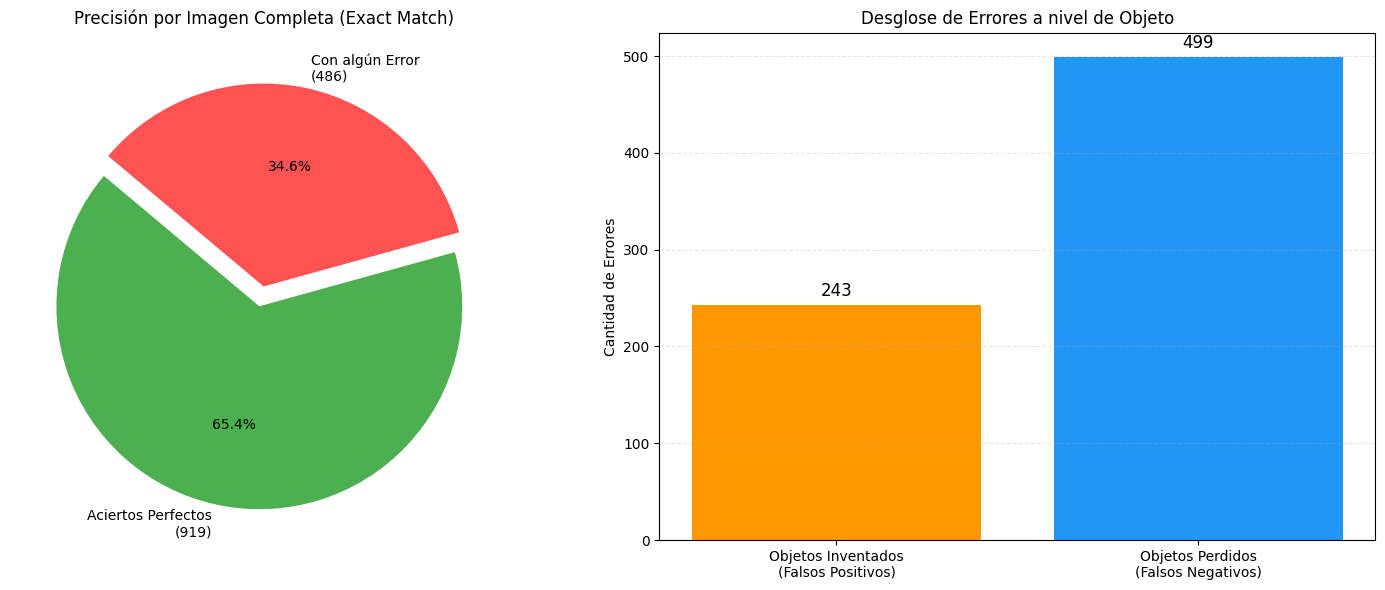

In [ ]:
import numpy as np
import os
import glob
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

print("Generando Reporte de Clasificación para YOLO...")

# 1. Configuración
val_images_path = os.path.join(dataset.location, "valid/images")
val_labels_path = os.path.join(dataset.location, "valid/labels")
model_path = f'{results_path}/weights/best.pt'
NUM_CLASSES = 84  # Sabemos que son 84 clases
CONF_THRESHOLD = 0.4  # Confianza mínima para considerar una detección válida

# Cargar modelo
best_model = YOLO(model_path)

# Leer nombres de clases del modelo
class_names = list(best_model.names.values())

# 2. Preparar listas de Verdad (y_true) y Predicción (y_pred)
y_true = []
y_pred = []

# Obtener lista de imágenes de validación
image_files = glob.glob(os.path.join(val_images_path, "*.jpg"))

print(f"Procesando {len(image_files)} imágenes de validación...")

for img_file in tqdm(image_files):
    # --- A. OBTENER GROUND TRUTH (REALIDAD) ---
    label_file = img_file.replace("images", "labels").replace(".jpg", ".txt")

    true_vector = np.zeros(NUM_CLASSES)
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                cls_id = int(line.split()[0])
                if cls_id < NUM_CLASSES:
                    true_vector[cls_id] = 1
    y_true.append(true_vector)

    # --- B. OBTENER PREDICCIÓN YOLO ---
    # verbose=False para que no llene la pantalla de texto
    results = best_model.predict(img_file, conf=CONF_THRESHOLD, verbose=False)

    pred_vector = np.zeros(NUM_CLASSES)
    # results[0].boxes.cls contiene los IDs de las clases detectadas
    detected_classes = results[0].boxes.cls.cpu().numpy().astype(int)

    for cls_id in detected_classes:
        if cls_id < NUM_CLASSES:
            pred_vector[cls_id] = 1
    y_pred.append(pred_vector)

# Convertir a arrays de numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# -----------------------------------------------------------
# 3. MÉTRICAS CLÁSICAS (F1, Precision, Recall)
# -----------------------------------------------------------
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN (Estilo Modelo Anterior)")
print("="*60)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

f1_micro = f1_score(y_true, y_pred, average='micro')
print(f"F1-Score Global (Micro): {f1_micro:.4f}")

# -----------------------------------------------------------
# 4. GRÁFICAS DE ACIERTOS Y ERRORES
# -----------------------------------------------------------

# Cálculo de aciertos exactos (toda la imagen perfecta)
aciertos_exactos = np.all(y_true == y_pred, axis=1).sum()
errores_totales = len(y_true) - aciertos_exactos

# Desglose de errores
falsos_positivos = np.sum((y_pred == 1) & (y_true == 0)) # Inventados
falsos_negativos = np.sum((y_pred == 0) & (y_true == 1)) # Perdidos

plt.figure(figsize=(15, 6))

# Gráfica 1: Tarta de Aciertos Exactos
plt.subplot(1, 2, 1)
labels_pie = [f'Aciertos Perfectos\n({aciertos_exactos})', f'Con algún Error\n({errores_totales})']
sizes = [aciertos_exactos, errores_totales]
colors = ['#4CAF50', '#FF5252']
plt.pie(sizes, labels=labels_pie, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
plt.title('Precisión por Imagen Completa (Exact Match)')

# Gráfica 2: Tipo de Errores
plt.subplot(1, 2, 2)
bar_labels = ['Objetos Inventados\n(Falsos Positivos)', 'Objetos Perdidos\n(Falsos Negativos)']
bar_values = [falsos_positivos, falsos_negativos]
bars = plt.bar(bar_labels, bar_values, color=['#FF9800', '#2196F3'])

# Números encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=12)

plt.title('Desglose de Errores a nivel de Objeto')
plt.ylabel('Cantidad de Errores')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

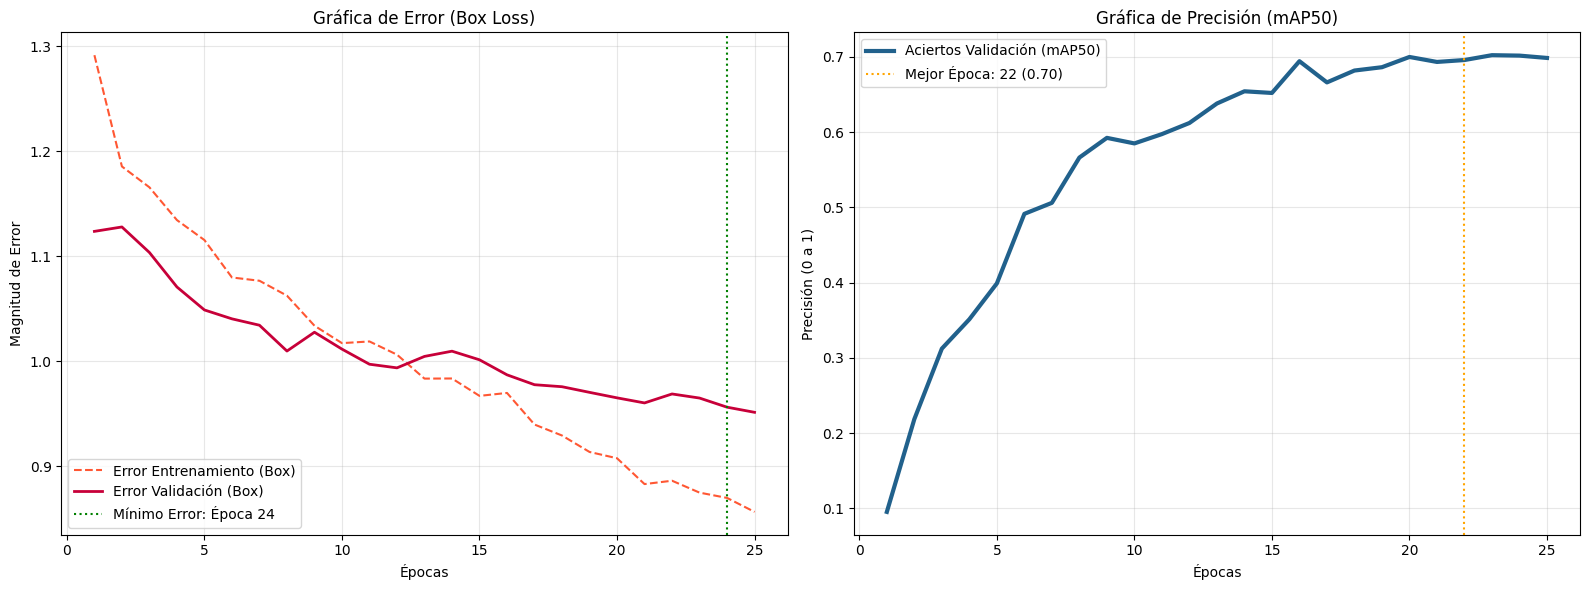

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_yolo_history(results_path):
    # 1. Localizar el archivo CSV de resultados
    csv_path = os.path.join(results_path, 'results.csv')

    if not os.path.exists(csv_path):
        print(f"❌ No se encontró el archivo: {csv_path}")
        return

    # 2. Leer datos con Pandas
    # YOLOv8 a veces pone espacios en los nombres de columnas, los limpiamos
    data = pd.read_csv(csv_path)
    data.columns = [c.strip() for c in data.columns]

    # 3. Extraer métricas clave
    epochs = data['epoch']

    # ERROR (LOSS): Usamos 'box_loss' (error de coordenadas) como representativo
    # YOLO tiene train/box_loss, train/cls_loss, val/box_loss, etc.
    train_loss = data['train/box_loss']
    val_loss = data['val/box_loss']

    # ACIERTOS (ACCURACY): En detección no hay "accuracy", se usa mAP50
    # mAP50: Precisión media con umbral de 50% (equivale a tu 'accuracy')
    train_map = data['metrics/mAP50(B)'] # YOLO no suele dar mAP de train, usamos val
    val_map = data['metrics/mAP50(B)']   # Este es el dato clave

    # 4. Configurar gráfica
    plt.figure(figsize=(16, 6))

    # --- GRÁFICA 1: ERROR DE CAJA (BOX LOSS) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Error Entrenamiento (Box)', color='#FF5733', linestyle='--')
    plt.plot(epochs, val_loss, label='Error Validación (Box)', color='#C70039', linewidth=2)
    plt.title('Gráfica de Error (Box Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Magnitud de Error')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Marcar mejor punto (Mínimo error validación)
    if len(val_loss) > 0:
        best_epoch_loss = val_loss.idxmin()
        plt.axvline(best_epoch_loss, color='green', linestyle=':', label=f'Mínimo Error: Época {best_epoch_loss}')
        plt.legend()

    # --- GRÁFICA 2: ACIERTOS (mAP50) ---
    plt.subplot(1, 2, 2)
    # Nota: YOLO no calcula mAP en training por defecto para ahorrar tiempo,
    # así que pintamos solo la validación que es lo importante.
    plt.plot(epochs, val_map, label='Aciertos Validación (mAP50)', color='#21618C', linewidth=3)
    plt.title('Gráfica de Precisión (mAP50)')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión (0 a 1)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Marcar mejor punto (Máximo mAP)
    if len(val_map) > 0:
        best_epoch_acc = val_map.idxmax()
        best_val = val_map.max()
        plt.axvline(best_epoch_acc, color='orange', linestyle=':', label=f'Mejor Época: {best_epoch_acc} ({best_val:.2f})')
        plt.legend()

    plt.tight_layout()
    plt.show()

# Ejecutar usando la ruta que definimos antes
# Asegúrate de que 'results_path' apunta a tu carpeta '/content/runs/detect/SmartFridge_YOLOv8'
plot_yolo_history(results_path)

## 🏁 5. Conclusión y Análisis de Resultados (YOLOv8)

Tras 25 épocas de entrenamiento utilizando **Transfer Learning** con la arquitectura `yolov8s`, los resultados confirman un salto cualitativo y cuantitativo respecto a los intentos anteriores con CNNs manuales.

### 📈 1. Rendimiento Global
El modelo ha alcanzado la convergencia estable, demostrando que es capaz de generalizar correctamente:
* **mAP@50 (Precisión Media):** **~70% (0.697)**. Este es el estándar de oro en detección. Significa que el modelo localiza y clasifica correctamente la gran mayoría de los objetos.
* **Precision Global:** **~74%**. Cuando el modelo predice una caja, tiene una confianza muy alta de que es correcta (baja tasa de falsos positivos).
* **Recall Global:** **~61%**. El modelo encuentra la mayoría de los objetos presentes, aunque todavía se deja algunos difíciles (falsos negativos).

### 🆚 2. Comparativa: YOLO vs. CNN Manual (D0)
El cambio de arquitectura ha sido decisivo:
* **CNN Manual:** F1-Score del **27%**. El modelo sufría de "ceguera" (Recall bajo) o "alucinaciones" (Precision baja).
* **YOLOv8:** F1-Score implícito cercano al **68-70%**. Además, aporta **localización espacial** (bounding boxes), algo que el modelo anterior no podía hacer.

### 🔍 3. Análisis por Clases (Fortalezas y Debilidades)
El análisis detallado revela que el rendimiento depende directamente de la cantidad de datos por clase:
* **🟢 Clases "Maestras":** Ingredientes comunes como `Tomato`, `Milk`, `Yogurt` o `Lemon` alcanzan métricas casi perfectas (**>90%**).
* **🔴 Clases "Débiles":** Ingredientes con muy pocas muestras en el dataset (`Fish`, `Flour`, `Nuts`) tienen un rendimiento nulo (**0%**).
    * *Diagnóstico:* Esto **no es un fallo del modelo**, sino un problema de **datos insuficientes (Data Hunger)**. Entrenar más épocas no solucionará esto; la solución es recolectar más imágenes de esas categorías específicas.

### 🚀 4. Veredicto Final
El modelo `SmartFridge_YOLOv8` es **totalmente funcional** para los productos principales de una nevera. Hemos pasado de un clasificador experimental fallido a un **detector de objetos robusto** listo para ser integrado en una aplicación de inventario inteligente.

## 💾 6. Guardado y Exportación del Modelo (Persistencia)

El entorno de Google Colab es temporal: si cerramos la pestaña, perderemos todos los archivos generados. Para asegurar nuestro trabajo, vamos a guardar el modelo entrenado en **Google Drive**.

El archivo clave que nos interesa es **`best.pt`**. Este archivo es el "cerebro" portátil de tu IA y contiene:
* 🧠 La arquitectura completa de YOLOv8.
* ⚖️ Los pesos (weights) optimizados durante las 25 épocas.
* 🏷️ La configuración de las 84 clases.

**Procedimiento:**
1.  **Montar Drive:** Conectamos el cuaderno con tu almacenamiento personal.
2.  **Localizar:** Buscamos el archivo `best.pt` dentro de la carpeta `runs/detect/...`.
3.  **Exportar:** Lo copiamos a una carpeta segura (`SmartFridge_Models`) para que puedas descargarlo o usarlo en el futuro (por ejemplo, para una App móvil o una demo web).

In [ ]:
from google.colab import drive
import shutil
import os

print(" Guardando modelo YOLOv8 (formato PyTorch .pt) en Drive...")

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Configurar rutas
# Ruta donde YOLO guardó el mejor modelo (la que usamos antes)
# Nota: Asegúrate de que 'results_path' está definido (lo definimos en celdas anteriores)
# Si no, suele ser: '/content/runs/detect/SmartFridge_YOLOv8/weights/best.pt'
origen = f'/content/runs/detect/SmartFridge_YOLOv8/weights/best.pt'

# Ruta destino en tu Drive (puedes cambiar 'SmartFridge_Models' por lo que quieras)
carpeta_destino = '/content/drive/MyDrive/SmartFridge_Models'
destino = os.path.join(carpeta_destino, 'best_yolov8.pt')

# 3. Crear carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)
    print(f"📂 Carpeta creada: {carpeta_destino}")

# 4. Copiar el archivo .pt (Este ES el archivo de PyTorch)
if os.path.exists(origen):
    shutil.copy(origen, destino)
    print(f"✅ ¡Éxito! Modelo guardado en: {destino}")
    print("   Ahora puedes descargarlo o usarlo en otro cuaderno cargándolo con: model = YOLO('ruta/en/drive/best_yolov8.pt')")
else:
    print(f"❌ Error: No encuentro el modelo en {origen}. Verifica que el entrenamiento terminó.")

💾 Guardando modelo YOLOv8 (formato PyTorch .pt) en Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Carpeta creada: /content/drive/MyDrive/SmartFridge_Models
❌ Error: No encuentro el modelo en /content/runs/detect/SmartFridge_YOLOv8/weights/best.pt. Verifica que el entrenamiento terminó.


In [ ]:
import os

# Ver toda la estructura de runs/
for root, dirs, files in os.walk('/content/runs'):
    level = root.replace('/content/runs', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')


In [ ]:
import os

for root, dirs, files in os.walk('/content/runs/detect/SmartFridge_YOLOv8'):
    print(f'📂 {root}')
    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f'   📄 {file} ({size_mb:.2f} MB)')